PROBLEMÁTICA: O desempenho escolar anterior (SSC_Marks e HSC_Marks) e a frequência (Attendance_Percentage) influenciam o desempenho dos alunos no ensino superior (Grade)?

**Dados da base**
- Student_ID: Id do estudante
- Name: Nome
- Class: Classe
- SSC_Marks (SSC - Secondary School Certificate): Pontuação de notas obtidas no exame nacional realizado ao final do ensino secundário (10º ano).
- HSC_Marks (HSC - Higher Secondary Certificate): Pontuação de notas obtidas no exame nacional realizado ao final do ensino médio (12º ano).
- College_Marks: Notas da faculdade
- Attendance_Percentage: Percentual de presença do aluno;
- Grade: Desempenho acadêmico na graduação (ensino superior). - TARGET

**OBS: SSC e HSC são exames padronizados do sistema educacional da Índia. As variáveis representam a pontuação de desempenho obtido pelo estudante nesses exames.**

In [71]:
#Importação de bibliotecas necessárias
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV #

# Preparação dos Dados #

In [2]:
#Caminho para leitura do arquivo com pandas
caminho_zip = 'C:/Users/tmjbe/Downloads/archive.zip'
try:
    df = pd.read_csv(caminho_zip, compression='zip')
    print('Dados lidos')
    print(df.head())
except Exception as e:
    print('Erro ao tentar ler com pandas', e)

Dados lidos
  Student_ID       Name     Class  SSC_Marks  HSC_Marks  College_Marks  \
0      S1000  Student_0  Commerce        535        452            692   
1      S1001  Student_1  Commerce        494        535            551   
2      S1002  Student_2   Science        542        460            634   
3      S1003  Student_3   Science        441        483            686   
4      S1004  Student_4      Arts        427        544            569   

   Attendance_Percentage Grade  
0                  84.71     C  
1                  81.99     D  
2                  92.06     B  
3                  79.27     D  
4                  91.99    A+  


In [3]:
#Removendo colunas desnecessárias à análise
df.drop(columns=['Name', 'Student_ID', 'Class'], inplace=True)

In [4]:
df

,SSC_Marks,HSC_Marks,College_Marks,Attendance_Percentage,Grade
0,535,452,692,84.71,C
1,494,535,551,81.99,D
2,542,460,634,92.06,B
3,441,483,686,79.27,D
4,427,544,569,91.99,A+
...,...,...,...,...,...
995,516,515,612,96.43,A
996,481,594,662,96.28,A+
997,546,581,646,76.74,C
998,434,465,516,70.97,B


In [5]:
print(df.shape[0]) #ver quantidade de linhas
print(df.shape[1]) #ver quantidade de colunas
print(type(df))

1000
5
<class 'pandas.DataFrame'>


**1. Pré-processamento de dados**

In [6]:
#verificando informações básicas no df
df.info() 

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   SSC_Marks              1000 non-null   int64  
 1   HSC_Marks              1000 non-null   int64  
 2   College_Marks          1000 non-null   int64  
 3   Attendance_Percentage  1000 non-null   float64
 4   Grade                  1000 non-null   str    
dtypes: float64(1), int64(3), str(1)
memory usage: 39.2 KB


As colunas estão de acordo com o tipo correto.

In [7]:
#verificando se há presença de dados faltantes.
df.isnull().sum()
(df.isnull().sum() / len(df)) *100 #contando porcentagem de dados nulos

SSC_Marks                0.0
HSC_Marks                0.0
College_Marks            0.0
Attendance_Percentage    0.0
Grade                    0.0
dtype: float64

Não há a presença de dados faltantes.

In [8]:
#Verificação de dados únicos
df['Grade'].unique()

<StringArray>
['C', 'D', 'B', 'A+', 'A']
Length: 5, dtype: str

Os dados estão aparentemente limpos.

**2. Análise Univariada**

In [17]:
df.describe()

,SSC_Marks,HSC_Marks,College_Marks,Attendance_Percentage
count,1000.000000,1000.000000,1000.00000,1000.000000
mean,476.197000,524.016000,603.05800,79.953460
std,44.340617,43.946775,58.34812,11.753637
min,400.000000,450.000000,500.00000,60.030000
25%,437.000000,484.750000,552.00000,69.572500
50%,476.000000,523.500000,602.00000,80.570000
75%,516.000000,564.000000,655.25000,89.955000
max,550.000000,600.000000,700.00000,99.950000


Pelo observado os dados aparentam uma distribuição bem próxima da normal. Com média e mediana bem próximas ou a mesma para algumas colunas. Também não aparenta ter Outliers. 

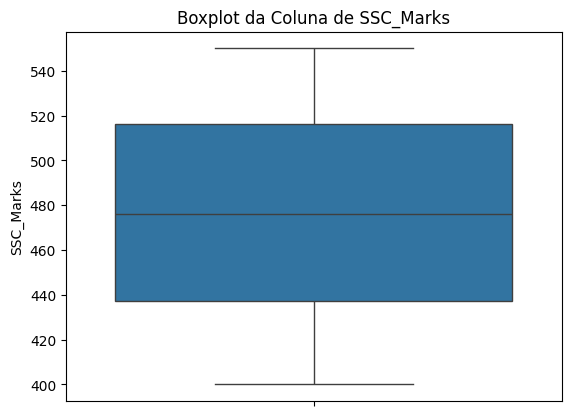

In [10]:
#Gráfico de análise univariada 
sns.boxplot(data=df, y='SSC_Marks')
plt.title('Boxplot da Coluna de SSC_Marks')
plt.show()

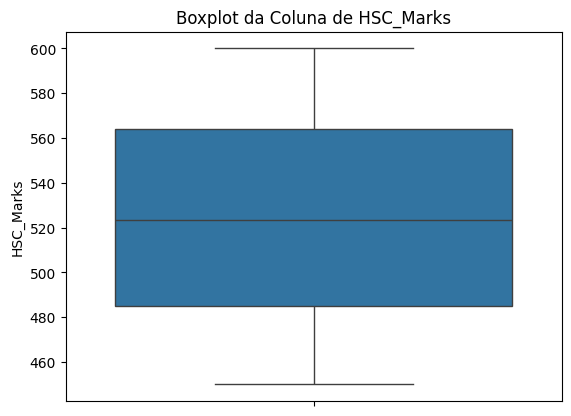

In [11]:
#Gráfico de análise univariada 
sns.boxplot(data=df, y='HSC_Marks')
plt.title('Boxplot da Coluna de HSC_Marks')
plt.show()

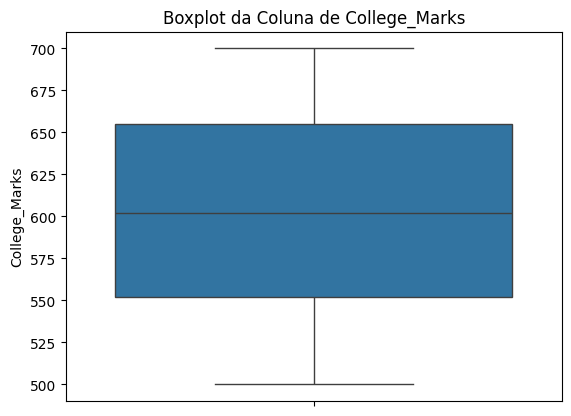

In [12]:
#Gráfico de análise univariada 
sns.boxplot(data=df, y='College_Marks')
plt.title('Boxplot da Coluna de College_Marks')
plt.show()

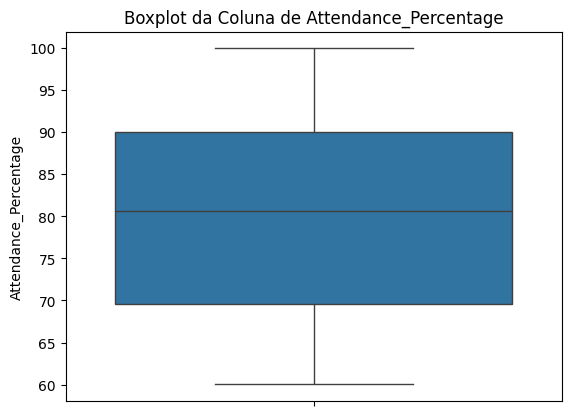

In [13]:
#Gráfico de análise univariada 
sns.boxplot(data=df, y='Attendance_Percentage')
plt.title('Boxplot da Coluna de Attendance_Percentage')
plt.show()

Os dados não possuem a presença de Outliers.

In [14]:
#Verificando balanceamento da Target
df['Grade'].value_counts(normalize=True) * 100

Grade
C     20.6
D     20.6
A+    20.2
B     19.3
A     19.3
Name: proportion, dtype: float64

Os dados da Target estão bem balanceados, portanto não há necessidade de melhorias.

**3. Análise Bivariada**

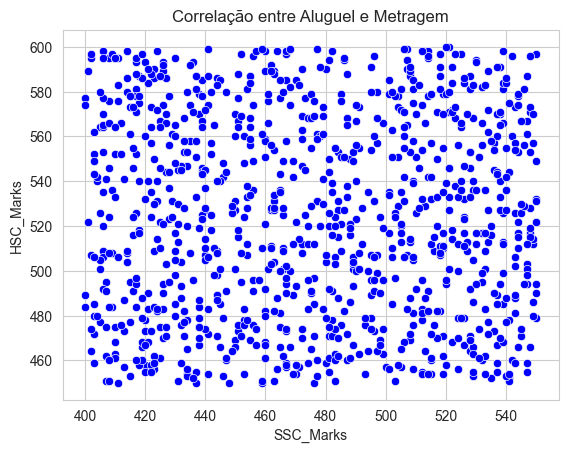

In [15]:
#Correlação entre notas.
sns.set_style("whitegrid")

sns.scatterplot(
    data=df,
    x='SSC_Marks',
    y='HSC_Marks',
    color='blue'
)

plt.title('Correlação entre Aluguel e Metragem')
plt.show()


In [16]:
fig = px.box(df,x='Grade' , y='College_Marks', title='Boxplot de height')
fig.show()

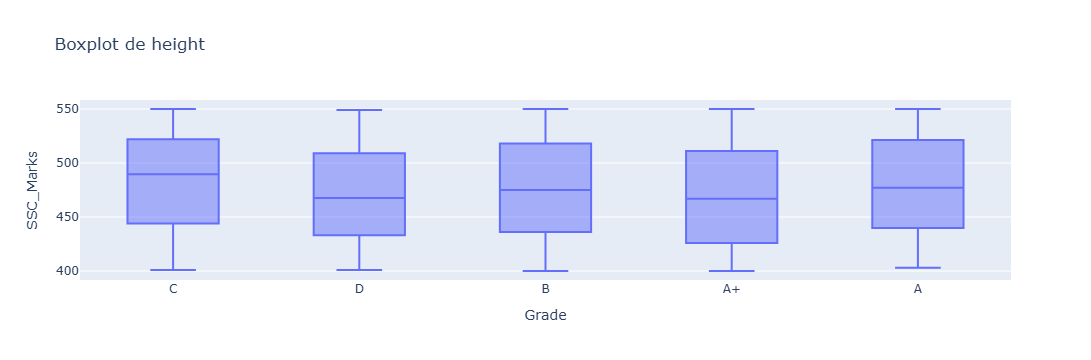

In [24]:
fig = px.box(df,x='Grade' , y='SSC_Marks', title='Boxplot de height')
fig.show()

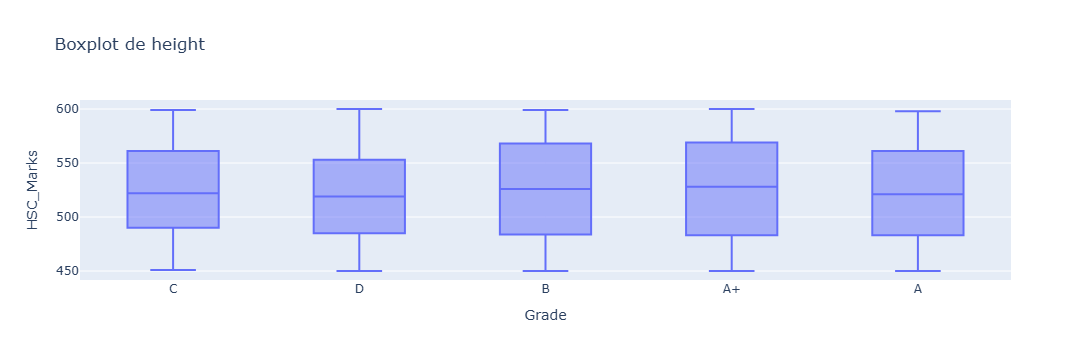

In [25]:
fig = px.box(df,x='Grade' , y='HSC_Marks', title='Boxplot de height')
fig.show()

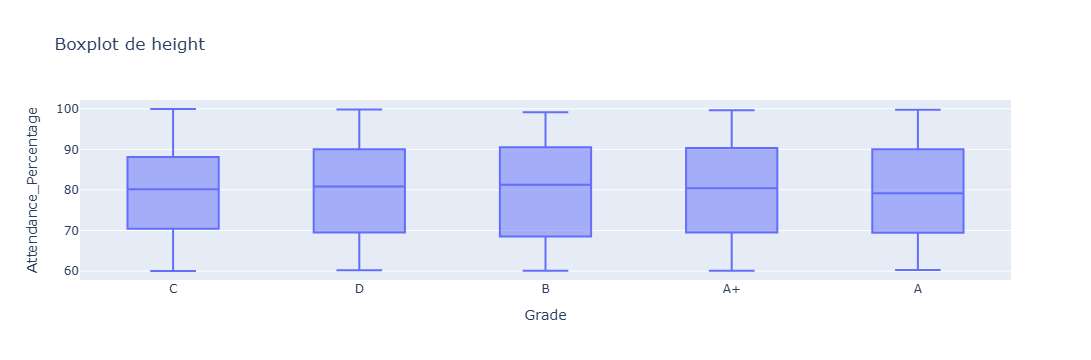

In [26]:
fig = px.box(df,x='Grade' , y='Attendance_Percentage', title='Boxplot de height')
fig.show()

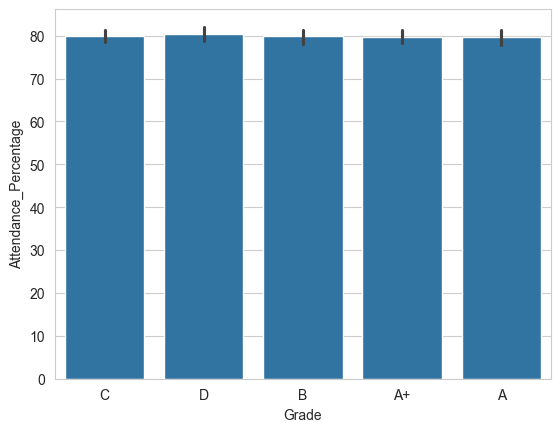

In [27]:
sns.barplot(x="Grade", y="Attendance_Percentage", data=df)
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

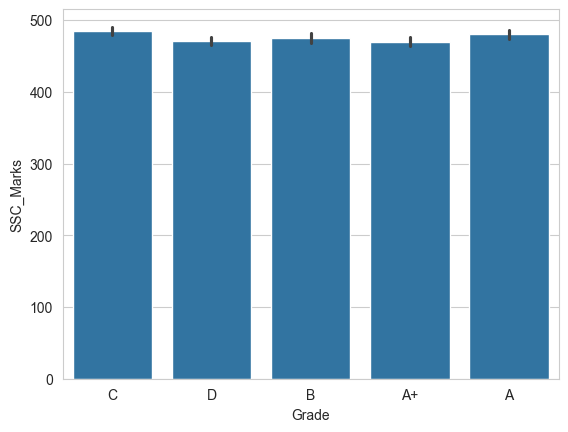

In [28]:
sns.barplot(x="Grade", y="SSC_Marks", data=df)
plt.show

Pelo observado nos dados as variáveis não aparentam ter tanta relação. Os dados parecem estar bem distuibuídos. 

In [28]:
#Transformando variáveis categóricas em numéricas
grade_map = {
    'D': 0,
    'C': 1,
    'B': 2,
    'A': 3,
    'A+': 4
}

df['grade_encoded'] = df['Grade'].map(grade_map)

In [30]:
df

,SSC_Marks,HSC_Marks,College_Marks,Attendance_Percentage,Grade,grade_encoded
0,535,452,692,84.71,C,1
1,494,535,551,81.99,D,0
2,542,460,634,92.06,B,2
3,441,483,686,79.27,D,0
4,427,544,569,91.99,A+,4
...,...,...,...,...,...,...
995,516,515,612,96.43,A,3
996,481,594,662,96.28,A+,4
997,546,581,646,76.74,C,1
998,434,465,516,70.97,B,2


In [41]:
#Excluindo coluna grade
df.drop(columns=['Grade'], inplace=True)

In [42]:
df

,SSC_Marks,HSC_Marks,College_Marks,Attendance_Percentage,grade_encoded
0,535,452,692,84.71,1
1,494,535,551,81.99,0
2,542,460,634,92.06,2
3,441,483,686,79.27,0
4,427,544,569,91.99,4
...,...,...,...,...,...
995,516,515,612,96.43,3
996,481,594,662,96.28,4
997,546,581,646,76.74,1
998,434,465,516,70.97,2


**4. Análise de Correlação** 

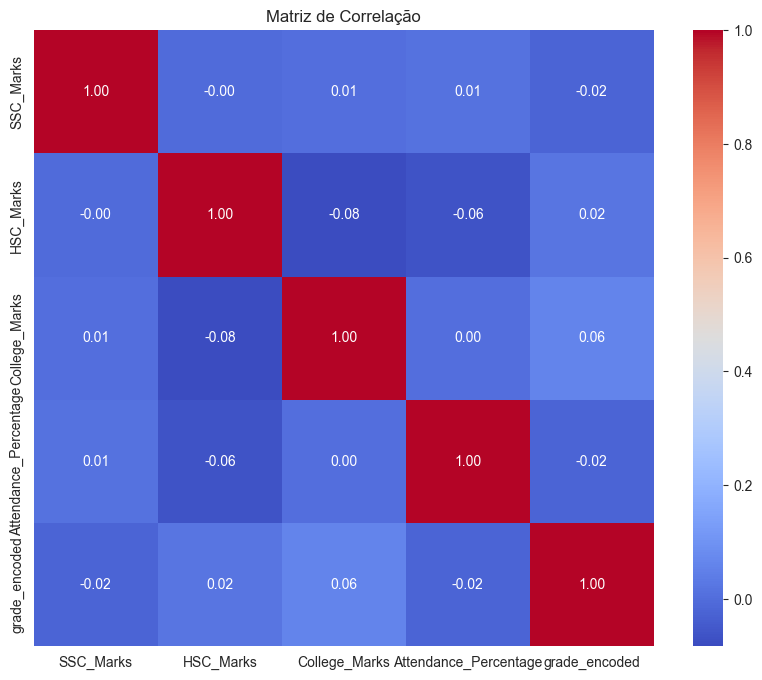

In [32]:
#Gráfico de correlação entre todas as variáveis.
corr_matriz = df.select_dtypes(include=['number']).corr()

# Plotar o mapa de calor da matriz de correlação
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matriz, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 10})
plt.title('Matriz de Correlação')
plt.show()

As variáveis de modo geral possuem baixíssima correlação, as que possuem a correlação maior com 'grade' é 'college_marks' com 0.06.

**5. Separação dos dados**

In [55]:
X = df[['SSC_Marks', 'HSC_Marks', 'Attendance_Percentage']]
Y = df[['grade_encoded']]

In [56]:
#Separando treino e teste
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)

In [57]:
#Padronizando os dados
sc = StandardScaler()

# Ajustando e transformando os dados de treino
X_train = sc.fit_transform(X_train)

# Transformando os dados de teste usando os parâmetros aprendidos dos dados de treino
X_test = sc.transform(X_test)

**6. Modelagem e Avaliação**

In [99]:
#Instanciando modelo de Ranfom Forest
modelo = RandomForestClassifier(random_state=42)
modelo.fit(X_train, Y_train)

C:\Users\tmjbe\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().



,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [100]:
#Verificando a features mais importantes para o modelo
print(modelo.feature_importances_)

[0.32124764 0.32089158 0.35786079]


In [101]:
#Relatório de Random Forest
previsao = modelo.predict(X_test)
relatorio = classification_report(Y_test, previsao)
print("Relatório de Classificação de Random Forest:")
print(relatorio)

Relatório de Classificação de Random Forest:
              precision    recall  f1-score   support

           0       0.27      0.32      0.29        38
           1       0.35      0.28      0.31        47
           2       0.24      0.10      0.14        49
           3       0.16      0.23      0.19        30
           4       0.17      0.25      0.20        36

    accuracy                           0.23       200
   macro avg       0.24      0.24      0.23       200
weighted avg       0.25      0.23      0.23       200



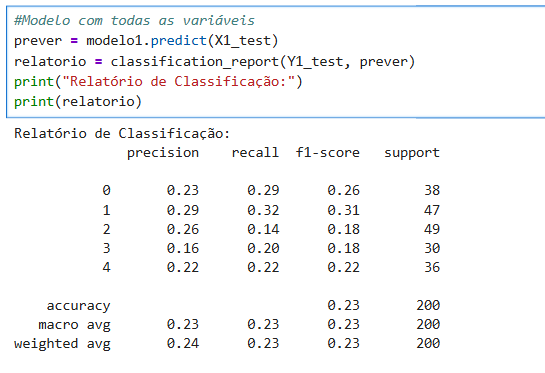


Apesar de não ser o objetivo do projeto testar o modelo com todas as variáveis, ele foi testado antes (imagem acima). A acurácia de ambos os modelos foi de 0.23, apenas algumas métricas que melhoraram no com as variáveis 'SSC_Marks', 'HSC_Marks', 'Attendance_Percentage' selecionadas, como a precisão para a classe 0 e 1, por outro lado houve piora para todas as métricas da classe 4. 

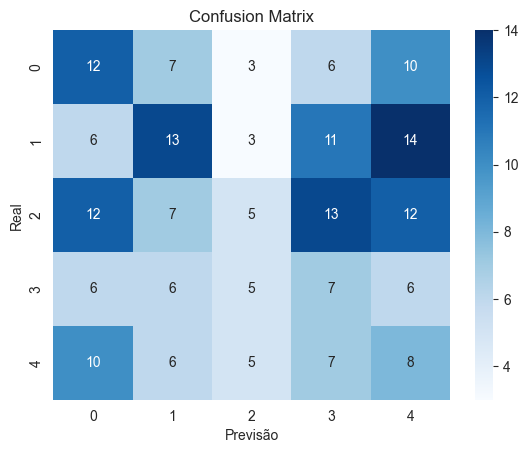

In [55]:
cm = confusion_matrix(Y_test, previsao)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Previsão")
plt.ylabel("Real")
plt.show()

As variáveis analisadas, isoladamente, não possuem forte poder explicativo sobre o desempenho universitário. O desempenho universitário provavelmente depende de fatores não presentes no dataset, as notas anteriores e frequência sozinhas talvez sejam insuficientes. Mesmo utilizando Random Forest, capaz de capturar relações não lineares, o modelo apresentou baixo desempenho, sugerindo que as variáveis analisadas possuem limitada capacidade preditiva sobre o desempenho acadêmico universitário.

# Testando com outros modelos #


In [58]:
#Árvore de Decisão
from sklearn.tree import DecisionTreeClassifier
arvore = DecisionTreeClassifier(criterion = 'gini', random_state = 0)
arvore.fit(X_train, Y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [60]:
#Prevendo dados no modelo de árvore
prever = arvore.predict(X_test)
relatorio = classification_report(Y_test, prever)
print("Relatório de Classificação de Árvore de Decisão:")
print(relatorio)

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.20      0.24      0.22        38
           1       0.24      0.21      0.22        47
           2       0.24      0.14      0.18        49
           3       0.17      0.23      0.20        30
           4       0.04      0.06      0.05        36

    accuracy                           0.17       200
   macro avg       0.18      0.18      0.17       200
weighted avg       0.19      0.17      0.18       200



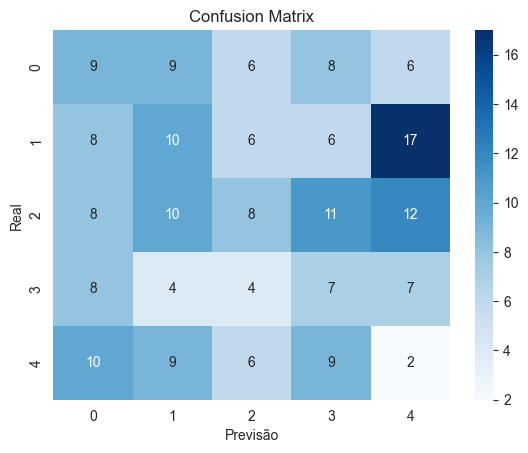

In [66]:
cm = confusion_matrix(Y_test, prever)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Previsão")
plt.ylabel("Real")
plt.show()

**XGBOOST**

In [63]:
#Instanciando modelo
xgboost = xgb.XGBClassifier(random_state=42)
xgboost.fit(X_train, Y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [64]:
#Validando xgb
xgb_prever = xgboost.predict(X_test)

In [68]:
#Relatório de XGBoost
relatorio_xgb = classification_report(Y_test, xgb_prever)
print('Relatório de Classificação\n', relatorio_xgb)

Relatório de Classificação
               precision    recall  f1-score   support

           0       0.25      0.32      0.28        38
           1       0.29      0.26      0.27        47
           2       0.26      0.12      0.17        49
           3       0.17      0.27      0.21        30
           4       0.20      0.22      0.21        36

    accuracy                           0.23       200
   macro avg       0.23      0.24      0.23       200
weighted avg       0.24      0.23      0.23       200



In [70]:
#Modelos com parâmetros
xgboost_param = xgb.XGBClassifier(random_state=42)

In [69]:
#Melhoramento de parâmetros
#Criando parâmetros
param_grid_xgb = {
    'n_estimators': [50, 100, 200, 250],
    'max_depth': [3, 4, 7],
    'learning_rate': [0.01, 0.1, 0.2, 0.6],
    'gama': [0, 0.1, 0.3],
    'reg_lambda': [1.0, 10.0],
    'subsample': [0.7, 0.8, 0.9],
    'eval_metric': ['auc', 'logloss']

}

In [76]:
#Aplicando GridSearchCV para melhores parâmetros
xgb_param = GridSearchCV(
    estimator= xgboost_param,
    param_grid=param_grid_xgb,
    scoring= 'accuracy',
    cv=3,
    n_jobs=-1
)

In [78]:
#Treinando modelo parametrizado
xgb_param.fit(X_train, Y_train)

C:\Users\tmjbe\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning:

[16:48:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "gama" } are not used.




,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'eval_metric': ['auc', 'logloss'], 'gama': [0, 0.1, ...], 'learning_rate': [0.01, 0.1, ...], 'max_depth': [3, 4, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and 

In [79]:
#Melhores parâmetros
print("Melhores Parâmetros:", xgb_param.best_params_)
print("Melhor Acurácia:", xgb_param.best_score_)

Melhores Parâmetros: {'eval_metric': 'auc', 'gama': 0, 'learning_rate': 0.6, 'max_depth': 4, 'n_estimators': 50, 'reg_lambda': 1.0, 'subsample': 0.7}
Melhor Acurácia: 0.2275304365783372


In [83]:
#Testando modelo
best_xg = xgb_param.best_estimator_
xgb_prever_para = best_xg.predict(X_test)

In [84]:
#Ver métricas
relatorio_model_xgb = classification_report(Y_test, xgb_prever_para)
print("Relatório de Classificação:")
print(relatorio_model_xgb)

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.21      0.29      0.24        38
           1       0.30      0.23      0.26        47
           2       0.18      0.12      0.15        49
           3       0.13      0.17      0.14        30
           4       0.16      0.17      0.16        36

    accuracy                           0.20       200
   macro avg       0.19      0.20      0.19       200
weighted avg       0.20      0.20      0.19       200



**SVM**

In [86]:
#Instanciando modelo
svm = SVC(random_state=42)
svm.fit(X_train, Y_train)

C:\Users\tmjbe\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().



,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [87]:
#Instanciando svm
svm_prever = svm.predict(X_test)

In [88]:
#Relatório de SVM
relatorio = classification_report(Y_test, svm_prever)
print("Relatório de Classificação:")
print(relatorio)

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.25      0.39      0.31        38
           1       0.27      0.32      0.29        47
           2       0.30      0.06      0.10        49
           3       0.12      0.13      0.13        30
           4       0.19      0.22      0.21        36

    accuracy                           0.23       200
   macro avg       0.23      0.23      0.21       200
weighted avg       0.24      0.23      0.21       200



In [89]:
#SVM parametrizado
svm_param = SVC(kernel='linear', random_state=42)

In [90]:
#Parametrizando
param_grid_svm = {
    'C': [0.5, 1.0, 10, 100],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': [0.1, 1.0],
    'probability': [True]
}

In [91]:
#Aplicando Grid no SVM
grid_svm = GridSearchCV(
    estimator=svm_param,
    param_grid=param_grid_svm,
    scoring='accuracy',
    cv=5,
    verbose=2,
    n_jobs=-1  
)

In [92]:
#Treinamento do modelo novo
grid_svm.fit(X_train, Y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


C:\Users\tmjbe\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().



,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC(kernel='l...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.5, 1.0, ...], 'gamma': [0.1, 1.0], 'kernel': ['linear', 'rbf', ...], 'probability': [True]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is dis

In [93]:
#Melhores parâmetros encontrados pelo Grid
best_param = grid_svm.best_params_
print(f"Melhores parâmetros: {best_param}")

Melhores parâmetros: {'C': 10, 'gamma': 0.1, 'kernel': 'linear', 'probability': True}


In [94]:
#Modelo com melhor parâmetros
best_svm_model = grid_svm.best_estimator_

In [95]:
#Validando modelo com dados
y_prever_svm = best_svm_model.predict(X_test)

In [97]:
#Relatório do modelo SVM parametrizado
relatorio = classification_report(Y_test, y_prever_svm)
print("Relatório de Classificação com o Melhor Modelo:")
print(relatorio)

Relatório de Classificação com o Melhor Modelo:
              precision    recall  f1-score   support

           0       0.15      0.21      0.18        38
           1       0.26      0.51      0.34        47
           2       0.00      0.00      0.00        49
           3       0.00      0.00      0.00        30
           4       0.14      0.19      0.16        36

    accuracy                           0.20       200
   macro avg       0.11      0.18      0.14       200
weighted avg       0.11      0.20      0.14       200



C:\Users\tmjbe\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

C:\Users\tmjbe\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

C:\Users\tmjbe\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



Foram testados alguns modelos para fazer as previsões. O primeiro deles foi o Random Forest que apresentou acurácia de 0.23, da mesma forma os modelos de XGBoost e SVM tiveram a mesma acurácia. O modelo que apresentou menores métricas foi o de Árvore de Decisão. Houve aplicação de parâmtros nos modelos de XGBoost e SVM mas houve piora nas métricas, com acurácia descendo para 0.20 e 0.16 respectivamente. De modo geral alguns modelos se apresentaram melhores na previsão de algumas classes, como foi o caso de RF para a precisão da classe 0, com 0.27, e SVM com recall para classe 0 de 0.39, e pra classe 2 de 0.30. Mas de maneira geral são valores muito baixos para prever as classes da target. A Matriz de Correlação havia mostrado a baixa relação entre esses dados, e mesmo a aplicação de modelos mais robustos como XGBoost e SVM não foram capazes de capturar muitas relaçãos, o que implica que provalmente os dados não são capazes de descriminar as classes. 